In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
# Import from the landlab library
from landlab import RasterModelGrid, imshow_grid, imshowhs_grid
from landlab.plot import plot_graph
import random as rng

In [17]:
def surf_plot(grid, surface="topographic__elevation", units='m', title="Topographic Elevation (3D)", elev=20, azim=-150, ax=None, cmap='gray', vmin=None, vmax=None):
    """
    Plot a Landlab grid's surface as a shaded 3D topography plot.

    Parameters
    ----------
    grid : RasterModelGrid
        The Landlab grid containing the surface to plot.
    surface : str, optional
        Name of the grid field to plot (default is "topographic__elevation").
    units : str, optional
        Units label to display on the axes (default is 'm').
    title : str, optional
        Title displayed above the plot (default is "Topographic Elevation (3D)").
    azim : float, optional
        Azimuthal viewing angle in degrees, controlling the plot's rotation
        (default is -150).
    ax : matplotlib.axes.Axes3D, optional
        An existing 3D axes to plot into. If None (default), a new standalone figure and axes are created.
    cmap : str, optional
        Name of the Matplotlib colormap used to color the surface by elevation
        (default is 'gray').
    vmin, vmax : float, optional
        Fixed lower/upper bounds for the z-axis and colorbar. If None (default), bounds are set automatically from the data's own
        min/max. Useful for anchoring the axes and colorbar to the same range across multiple calls (e.g. comparing several time steps),
        so scale doesn't shift from plot to plot.

    Returns
    -------
    None
        Displays the plot. If `ax` is provided, the plot is drawn into that
        axes and the figure is not shown automatically (the caller is
        responsible for calling plt.show()).

    Notes
    -----
    The colorbar range is explicitly normalized to the true min/max of the
    surface data using `norm`. Without this, plot_surface colors each face
    by averaging its corner values, which can visually compress the color
    range compared to a 2D plot of the same data (e.g. imshow_grid).
    """
    single_fig = ax is None
    if single_fig:
        fig = plt.figure(figsize=(10, 6))
        ax = fig.add_axes([0.05, 0.05, 0.75, 0.90], projection="3d") # for some reason this plot cuts off the z-axis label for certain 
                                                                      # orientations (azim=-70) so this forces it to a specific position for some of them 
    else:
        fig = ax.get_figure()
    # plot the surface
    z = grid.at_node[surface].reshape(grid.shape)

    # Use provided vmin/vmax if given, otherwise fall back to this data's own min/max
    if vmin is not None:
        zmin = vmin
    else:
        zmin = z.min()
    if vmax is not None:
        zmax = vmax
    else:
        zmax = z.max()

    norm = mcolors.Normalize(vmin=zmin, vmax=zmax)
    surf = ax.plot_surface(
                grid.x_of_node.reshape(grid.shape),
                grid.y_of_node.reshape(grid.shape),
                z,
                cmap=cmap,
                norm=norm,
                linewidth=0.0,
                antialiased=False,
    )
    ax.view_init(elev=elev, azim=azim)
    ax.set_zlim(zmin, zmax)
    ax.set_xlabel(f"x [{units}]")
    ax.set_ylabel(f"y [{units}]")
    ax.set_zlabel(f"elevation [{units}]")
    plt.title(title)
    fig.colorbar(surf, ax=ax, label=f"elevation [{units}]")
    if single_fig:
        plt.show()

def compare_2d_3d(grid, surface="topographic__elevation", units='m', elev=20, azim=-70 , cmap_3d='gray', vmin=None, vmax=None, plot_type=None):
    """
    Plot a Landlab grid's surface side by side as a 2D map view and a 3D
    shaded topography plot.

    Parameters
    ----------
    grid : RasterModelGrid
        The Landlab grid containing the surface to plot.
    surface : str, optional
        Name of the grid field to plot (default is "topographic__elevation").
    units : str, optional
        Units label to display on the 3D plot's axes (default is 'm').
    elev : float, optional
        Elevation viewing angle in degrees for the 3D plot, controlling
        how high the camera sits above the surface (default is 20).
    azim : float, optional
        Azimuthal viewing angle in degrees for the 3D plot, controlling its rotation (default is -70).
    cmap_3d : str, optional
        Name of the Matplotlib colormap used to color the 3D surface by elevation (default is 'gray').
    vmin, vmax : float, optional
        Fixed lower/upper bounds for the 3D plot's z-axis and colorbar. If None (default), bounds are set automatically from this surface's
        own min/max. Useful for anchoring the scale across multiple calls (e.g. comparing several time steps) so it doesn't shift between
        plots.
    plot_type : str, optional
        If set to 'hillshade', the 2D panel is drawn using Landlab's `imshowhs_grid` (shaded relief) instead of the default flat-color
        `imshow_grid`. Any other value (including None, the default) uses `imshow_grid`.

    Returns
    -------
    None
        Displays a single figure containing both the 2D and 3D plots side by side.

    Notes
    -----
    The 2D panel uses Landlab's `imshow_grid` (or `imshowhs_grid` if plot_type='hillshade'), which draws to whichever axes is "current" —
    `plt.sca(ax1)` is used to point it at the left subplot before calling it. The 3D panel is drawn using `surf_plot`, passed the right subplot
    directly via its `ax` argument.
    """
    
    fig = plt.figure(figsize=(10, 4))

    # left panel: 2D imshow
    ax1 = fig.add_subplot(1, 2, 1)
    plt.sca(ax1)  # tells imshow_grid to draw here
    if plot_type == 'hillshade':
        imshowhs_grid(grid, "topographic__elevation")
    else:
        imshow_grid(grid, surface, colorbar_label="Elevation (m)")
    ax1.set_title("Topographic Elevation (2D)")

    # right panel: 3D surface
    ax2 = fig.add_subplot(1, 2, 2, projection="3d")
    surf_plot(grid, surface=surface, units=units, azim=azim, ax=ax2, cmap=cmap_3d, vmin=vmin, vmax=vmax)
    plt.tight_layout()
    plt.show()

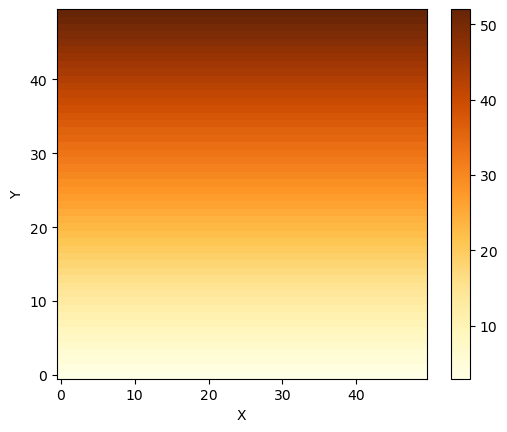

In [55]:
num_rows = 50  # number of grid rows
num_cols = 50  # number of grid columns
dxy = 1  # resolution of raster cell [m], or node horizontal and vertical spacing
grid = RasterModelGrid((num_rows, num_cols), dxy)

#create the initial simplified ramp topography
topo = grid.add_zeros('topographic__elevation', at='node')
cliff_height = 3 #working in meters
for i in range(num_rows):
    start = i * num_rows
    end = start + num_rows
    topo[start:end] = cliff_height
    cliff_height += 1
    
# Plot the topo map
imshow_grid(grid, "topographic__elevation",cmap="YlOrBr")

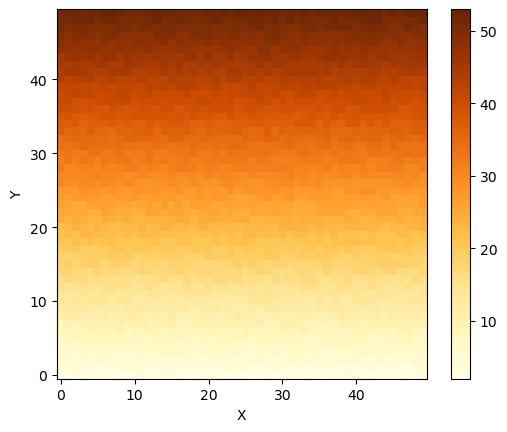

In [56]:
topo_noise = np.random.uniform(-1, 1, 2500)
topo += topo_noise

# Plot the topo map with noise
imshow_grid(grid, "topographic__elevation",cmap="YlOrBr")

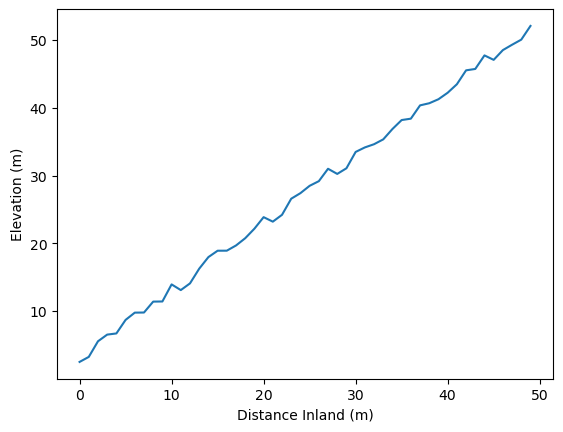

In [71]:
xnode_filter = np.isclose(grid.x_of_node, 5.0)
# Extract all values at that x-position for a specific field
values_at_x = grid.at_node['topographic__elevation'][xnode_filter]
values_at_x
plot(values_at_x)
plt.xlabel("Distance Inland (m)")
plt.ylabel("Elevation (m)")
plt.show()

In [45]:
sea_level = 6.0 #meters
erosion_rate = 10  #m/y or set zr[i] = sea_level to cut/flatten directly
uplift_rate_m_yr = 2.1/1000 # 2.1 mm/yr avg uplift
dt = 1000 # timestep (yr)
uplift = uplift_rate_m_yr * dt
time_to_run = 1e6  # time for the model loop to run [yr]
nsteps = int(time_to_run / dt)  # number of model time steps
plot_interval = 200    # how often (in years) to print progress and plot

In [24]:
print(nsteps)

1000


Time: 0 yr


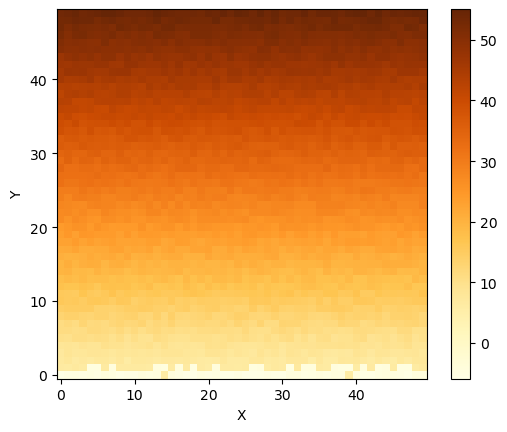

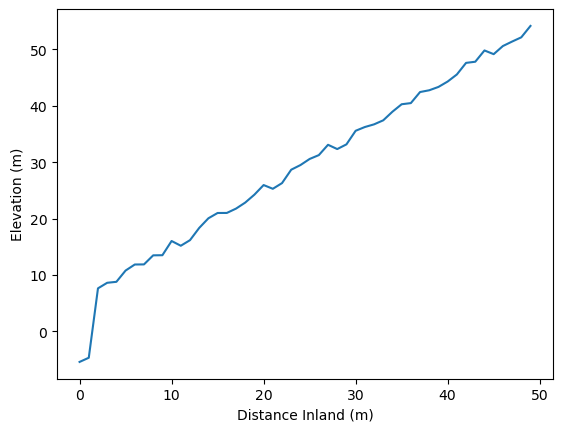

Time: 200000 yr


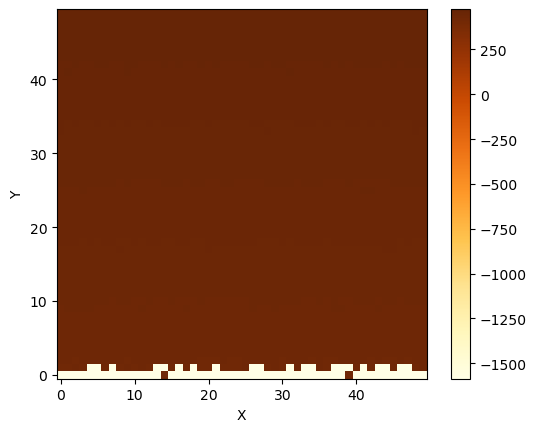

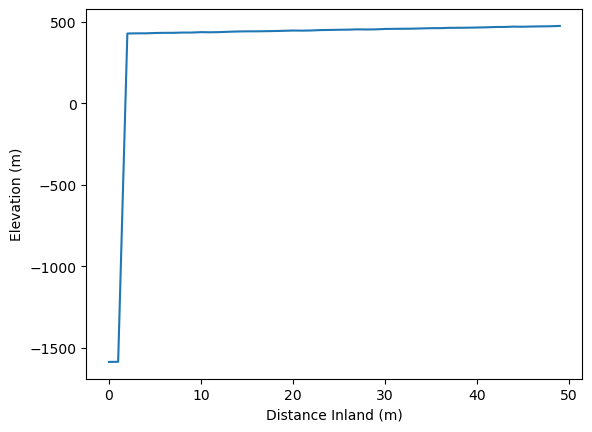

Time: 400000 yr


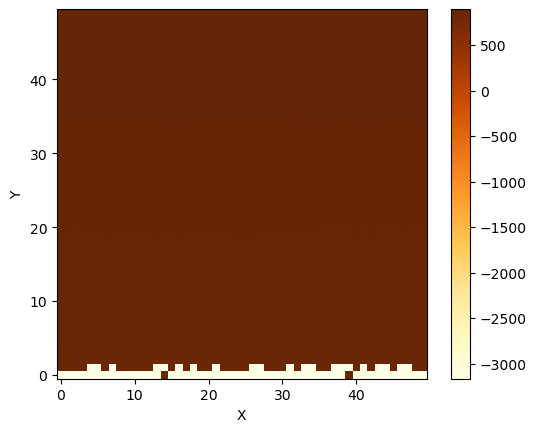

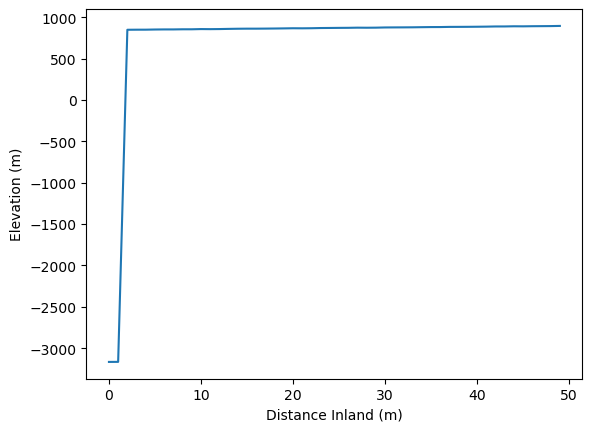

Time: 600000 yr


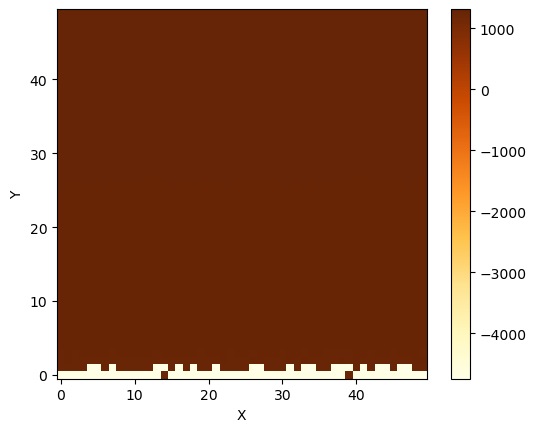

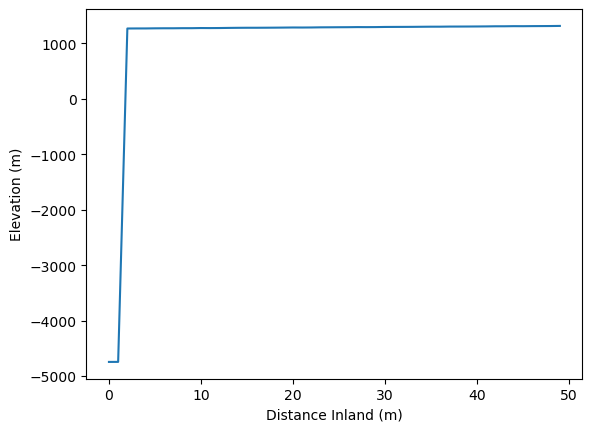

Time: 800000 yr


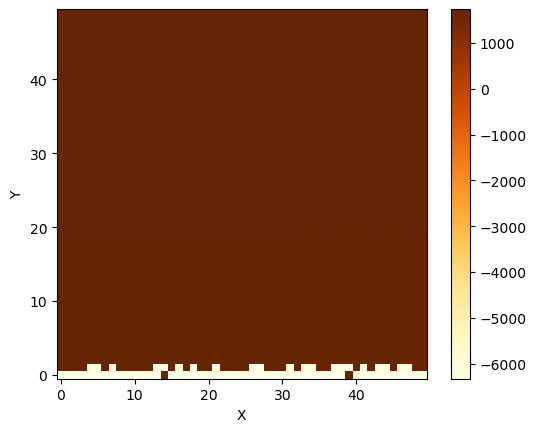

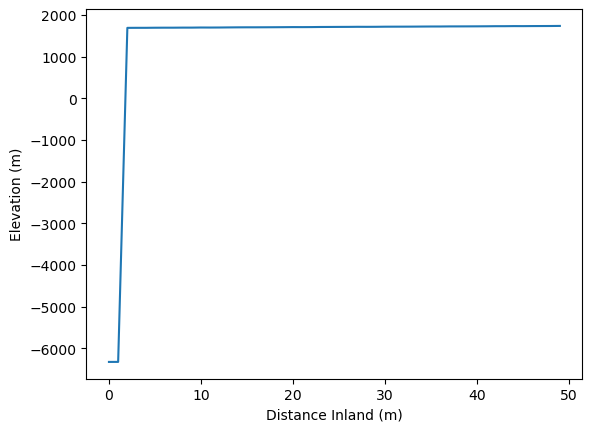

Time: 1000000 yr


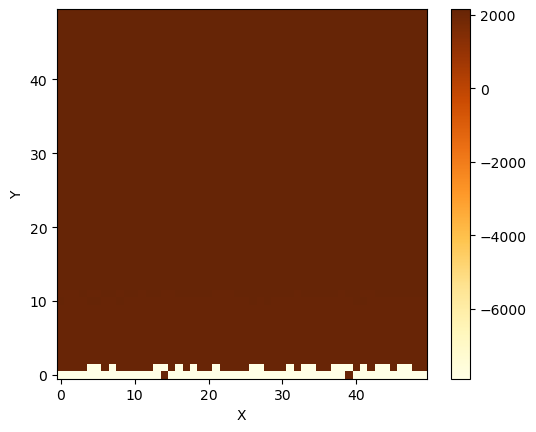

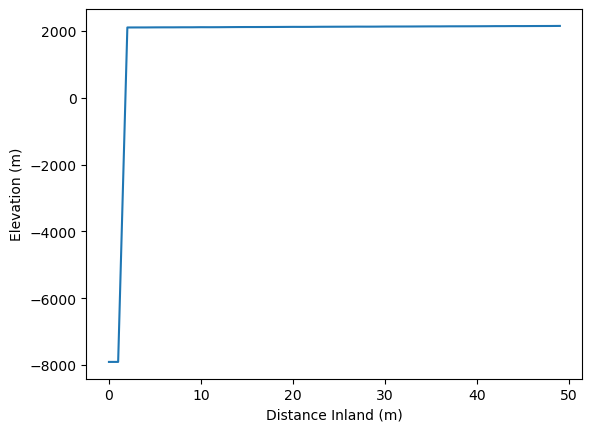

In [72]:
for step in range (nsteps+1):
    # Loop over every node on the grid (removed the + 1)
    for i in range(grid.number_of_nodes):
        topo[i]+= uplift
        if topo[i] < sea_level:
            topo[i] -= erosion_rate  # Erode node if it is underwater
    # plot at the plot_interval to show the current state of hte hillslope
    if step % plot_interval == 0:
        print(f"Time: {step*1000} yr")
        imshow_grid(grid, "topographic__elevation",cmap="YlOrBr")
        plt.show()

        xnode_filter = np.isclose(grid.x_of_node, 5.0)
        # Extract all values at that x-position for a specific field
        values_at_x = grid.at_node['topographic__elevation'][xnode_filter]
        values_at_x
        plot(values_at_x)
        plt.xlabel("Distance Inland (m)")
        plt.ylabel("Elevation (m)")
        plt.show()

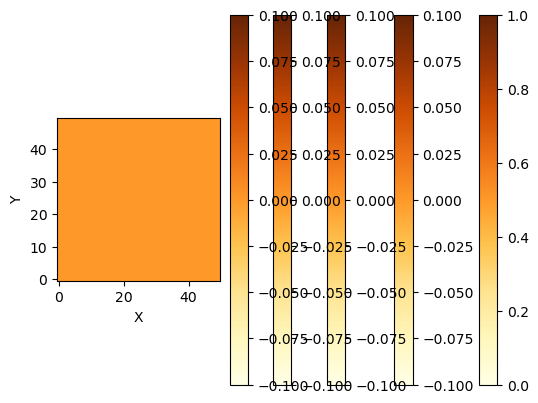

In [11]:
#ethans test
for step in range(5):
    topo += uplift
    #create boolian vector that shows which nodes are below sea level
    is_wet = np.where(topo < sea_level,1,0)
    #erode the nodes that are under sea level
    if is_wet:
        
# plotting
imshow_grid(grid, "topographic__elevation",cmap="YlOrBr")

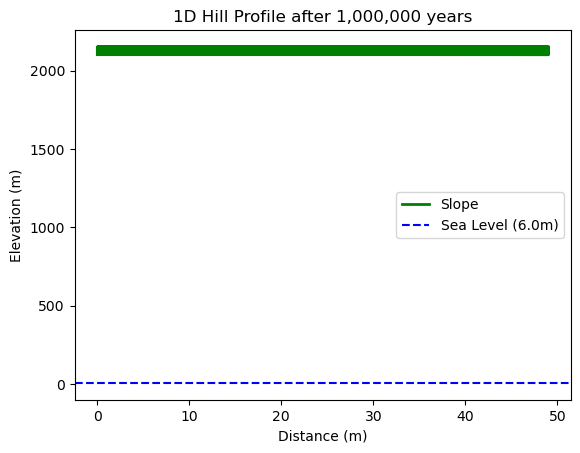

In [24]:
plt.plot(grid.node_x, topo, color='green', linewidth=2, label='Slope')
plt.axhline(sea_level, color='blue', linestyle='--', label='Sea Level (6.0m)')
plt.title(f'1D Hill Profile after {time_to_run:,.0f} years')
plt.xlabel('Distance (m)')
plt.ylabel('Elevation (m)')
plt.legend()
plt.show()

In [25]:
grid.node_x()

AttributeError: 'RasterModelGrid' object has no attribute 'nodex'